In [1]:
3+5

8

In [2]:
# Cell — Clear all existing data (run once to reset)
from db_connect import get_session
from db_models import Candidate, Education, Experience, Skill, Publication, Book, Patent, SupervisedStudent

session = get_session()
try:
    # Delete in child-first order (foreign keys)
    session.query(SupervisedStudent).delete()
    session.query(Patent).delete()
    session.query(Book).delete()
    session.query(Publication).delete()
    session.query(Skill).delete()
    session.query(Experience).delete()
    session.query(Education).delete()
    session.query(Candidate).delete()
    session.commit()
    print("✅ All tables cleared")
except Exception as e:
    session.rollback()
    print(f"❌ Error: {e}")
finally:
    session.close()

✅ All tables cleared


In [3]:
# Cell — DROP and RECREATE all tables (Run once to reset schema and data)
from db_connect import engine, init_db
from db_models import Base

try:
    # 1. This completely destroys all existing tables in the database
    Base.metadata.drop_all(engine)
    print("🗑️ All old tables completely dropped.")

    # 2. This recreates them using your updated db_models.py
    init_db()
    print("✨ Fresh tables created with the new columns!")

except Exception as e:
    print(f"❌ Error: {e}")

🗑️ All old tables completely dropped.
✅ All tables created
✨ Fresh tables created with the new columns!


In [4]:
# Cell 1 — Imports
import os
import re
import json
import operator
import fitz  # PyMuPDF
from typing import Annotated, List, Optional, Literal, TypedDict
from pydantic import BaseModel, Field, field_validator
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

c:\Projects\Talash\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Create LLM
from dotenv import load_dotenv
import os
import fitz


load_dotenv()
openrouter_key=os.getenv("OPENROUTER_API_KEY")
llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    api_key=openrouter_key,
    base_url="https://openrouter.ai/api/v1",
    temperature=0.7
)

# Test
response = llm.invoke("Explain batch normalization in simple terms")
print(response.content)

Batch normalization is a technique used in deep learning to make training neural networks faster and more stable. Here's a simple breakdown of how it works:

1. **Why It’s Needed**: When training deep learning models, the distribution of inputs to each layer can change as the model learns. This change can slow down training and make it harder for the model to converge (find the best weights).

2. **What It Does**: Batch normalization normalizes the inputs to a layer by adjusting and scaling them. Specifically, it takes the average and standard deviation of the inputs for a mini-batch of data (a small group of training examples) and uses these to adjust the inputs so that they have a mean of 0 and a variance of 1.

3. **How It Works**: 
   - For each mini-batch of data, it calculates the mean and variance of the activations (the outputs of the previous layer).
   - It then normalizes these activations using the mean and variance.
   - Finally, it applies a scale and shift transformation

In [6]:
# Cell 3 — State
class CVState(TypedDict):
    pdf_path:    str
    raw_texts:   Annotated[List[tuple], operator.add]
    all_results: Annotated[List[dict],  operator.add]
    error:       Optional[str]

In [7]:
# Cell 4 — Pydantic schemas

class PersonalInfo(BaseModel):
    name:  Optional[str] = None
    email: Optional[str] = None
    phone: Optional[str] = None

class DegreeRecord(BaseModel):
    degree:     Optional[str]   = None   # "PhD","MS","BS","HSSC","SSC"
    field:      Optional[str]   = None
    institution:Optional[str]   = None
    start_year: Optional[int]   = None
    end_year:   Optional[int]   = None
    cgpa:       Optional[float] = None
    cgpa_scale: Optional[float] = None
    percentage: Optional[float] = None
    board:      Optional[str]   = None   # SSC/HSSC only

    @field_validator("start_year", "end_year", mode="before")
    @classmethod
    def parse_year(cls, v):
        if v is None or str(v).strip().lower() in {"n/a","na","none","null",""}:
            return None
        match = re.search(r"\b(19|20)\d{2}\b", str(v))
        return int(match.group()) if match else None

    @field_validator("cgpa","cgpa_scale","percentage", mode="before")
    @classmethod
    def parse_float(cls, v):
        if v is None or str(v).strip().lower() in {"n/a","na","none","null",""}:
            return None
        try:
            return float(str(v).replace("%","").replace("/4.0","").replace("/5.0","").strip())
        except:
            return None

class ExperienceRecord(BaseModel):
    company:         Optional[str] = None
    role:            Optional[str] = None
    employment_type: Optional[str] = None
    start_date:      Optional[str] = None
    end_date:        Optional[str] = None
    description:     Optional[str] = None

    @field_validator("start_date","end_date", mode="before")
    @classmethod
    def parse_date(cls, v):
        if v is None or str(v).strip().lower() in {
            "n/a","na","none","null","","present","current","till date","to date"
        }:
            return None
        v = str(v).strip()
        if re.match(r"^\d{4}-\d{1,2}$", v):
            parts = v.split("-")
            return f"{parts[0]}-{int(parts[1]):02d}"
        months = {
            "jan":1,"feb":2,"mar":3,"apr":4,"may":5,"jun":6,
            "jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12
        }
        # handles "Sep-2017", "Sep 2017", "September 2017"
        match = re.search(
            r"(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[a-z]*[\s,.\-]+(\d{4})",
            v.lower()
        )
        if match:
            return f"{match.group(2)}-{months[match.group(1)[:3]]:02d}"
        # reversed "2017-Sep"
        match = re.search(
            r"(\d{4})[\s,.\-]+(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[a-z]*",
            v.lower()
        )
        if match:
            return f"{match.group(1)}-{months[match.group(2)[:3]]:02d}"
        match = re.search(r"\b(19|20)\d{2}\b", v)
        if match:
            return match.group()
        return None

class Publication(BaseModel):
    type:             Literal["journal","conference"] = "journal"
    title:            Optional[str]   = None
    venue:            Optional[str]   = None
    issn:             Optional[str]   = None
    year:             Optional[int]   = None
    authors:          List[str]       = Field(default_factory=list)
    authorship_role:  Optional[Literal[
        "first","corresponding","first_and_corresponding","co_author"
    ]] = None
    wos_indexed:      Optional[bool]  = None
    scopus_indexed:   Optional[bool]  = None
    quartile:         Optional[Literal["Q1","Q2","Q3","Q4"]] = None
    impact_factor:    Optional[float] = None
    core_rank:        Optional[str]   = None
    indexed_in:       Optional[str]   = None

    @field_validator("year", mode="before")
    @classmethod
    def parse_year(cls, v):
        if v is None or str(v).strip().lower() in {"n/a","na","none","null",""}:
            return None
        match = re.search(r"\b(19|20)\d{2}\b", str(v))
        return int(match.group()) if match else None

class Book(BaseModel):
    title:           Optional[str] = None
    authors:         List[str]     = Field(default_factory=list)
    isbn:            Optional[str] = None
    publisher:       Optional[str] = None
    year:            Optional[int] = None
    url:             Optional[str] = None
    authorship_role: Optional[Literal["sole","lead","co_author","contributing"]] = None

    @field_validator("year", mode="before")
    @classmethod
    def parse_year(cls, v):
        if v is None or str(v).strip().lower() in {"n/a","na","none","null",""}:
            return None
        match = re.search(r"\b(19|20)\d{2}\b", str(v))
        return int(match.group()) if match else None

class Patent(BaseModel):
    patent_number:    Optional[str] = None
    title:            Optional[str] = None
    year:             Optional[int] = None
    inventors:        List[str]     = Field(default_factory=list)
    country:          Optional[str] = None
    verification_url: Optional[str] = None

    @field_validator("year", mode="before")
    @classmethod
    def parse_year(cls, v):
        if v is None or str(v).strip().lower() in {"n/a","na","none","null",""}:
            return None
        match = re.search(r"\b(19|20)\d{2}\b", str(v))
        return int(match.group()) if match else None

class SupervisionRecord(BaseModel):
    student_name:    Optional[str] = None
    level:           Optional[Literal["MS","PhD"]] = None
    role:            Optional[Literal["main","co_supervisor"]] = None
    graduation_year: Optional[int] = None

    @field_validator("graduation_year", mode="before")
    @classmethod
    def parse_year(cls, v):
        if v is None or str(v).strip().lower() in {"n/a","na","none","null",""}:
            return None
        match = re.search(r"\b(19|20)\d{2}\b", str(v))
        return int(match.group()) if match else None

class CVExtraction(BaseModel):
    personal_info:      PersonalInfo          = Field(default_factory=PersonalInfo)
    education:          List[DegreeRecord]    = Field(default_factory=list)
    experience:         List[ExperienceRecord]= Field(default_factory=list)
    skills:             List[str]             = Field(default_factory=list)
    publications:       List[Publication]     = Field(default_factory=list)
    books:              List[Book]            = Field(default_factory=list)
    patents:            List[Patent]          = Field(default_factory=list)
    supervised_students:List[SupervisionRecord]=Field(default_factory=list)

structured_llm = llm.with_structured_output(CVExtraction)

In [8]:
# Cell 5 — Extraction prompt (field names match Pydantic exactly)

EXTRACTION_PROMPT = """
You are a CV data extraction assistant. Extract structured information from the CV text below.
Return a JSON object that EXACTLY matches this schema. Use these EXACT field names.

SCHEMA:
{{
  "personal_info": {{
    "name": string or null,
    "email": string or null,
    "phone": string or null
  }},
  "education": [
    {{
      "degree": string or null,        // e.g. "PhD", "MS", "BS", "HSSC", "SSC"
      "field": string or null,         // specialization e.g. "Electrical Engineering"
      "institution": string or null,
      "start_year": integer or null,   // e.g. 2020 — integer only
      "end_year": integer or null,     // e.g. 2024 — integer only
      "cgpa": float or null,           // e.g. 3.83 — float only
      "cgpa_scale": float or null,     // 4.0 or 5.0 — infer from context if possible
      "percentage": float or null,     // e.g. 71.5 — float only
      "board": string or null          // only for SSC/HSSC e.g. "BISE Lahore"
    }}
  ],
  "experience": [
    {{
      "company": string or null,
      "role": string or null,
      "employment_type": string or null,
      "start_date": string or null,    // MUST be "YYYY-MM" e.g. "2017-09"
      "end_date": string or null,      // MUST be "YYYY-MM" or null if present/current
      "description": string or null
    }}
  ],
  "skills": [string],
  "publications": [
    {{
      "type": "journal" or "conference",
      "title": string or null,
      "venue": string or null,
      "issn": string or null,
      "year": integer or null,
      "authors": [string],
      "authorship_role": "first" or "corresponding" or "first_and_corresponding" or "co_author" or null,
      "wos_indexed": boolean or null,
      "scopus_indexed": boolean or null,
      "quartile": "Q1" or "Q2" or "Q3" or "Q4" or null,
      "impact_factor": float or null,
      "core_rank": string or null,
      "indexed_in": string or null
    }}
  ],
  "books": [
    {{
      "title": string or null,
      "authors": [string],
      "isbn": string or null,
      "publisher": string or null,
      "year": integer or null,
      "url": string or null,
      "authorship_role": "sole" or "lead" or "co_author" or "contributing" or null
    }}
  ],
  "patents": [
    {{
      "patent_number": string or null,
      "title": string or null,
      "year": integer or null,
      "inventors": [string],
      "country": string or null,
      "verification_url": string or null
    }}
  ],
  "supervised_students": [
    {{
      "student_name": string or null,
      "level": "MS" or "PhD" or null,
      "role": "main" or "co_supervisor" or null,
      "graduation_year": integer or null
    }}
  ]
}}

STRICT RULES:
- Use null for every missing/unknown field — NEVER use "N/A", "Present", ""
- SSC and HSSC go inside the "education" list with degree="SSC" or degree="HSSC"
- ALL publications (journals + conferences) go in the single "publications" list
- Dates MUST be "YYYY-MM": convert "Sep-2017" to "2017-09"
- If end_date is "Present" or "current" use null
- Years must be integers, CGPA must be floats
- Extract ALL entries, never truncate

CV TEXT:
{cv_text}
"""

In [9]:
# Cell 6 — Post-processors

def clean_nulls(obj):
    NULL_STRINGS = {
        "n/a","na","none","null","not mentioned",
        "not available","not applicable","","-","present","current"
    }
    if isinstance(obj, dict):
        return {k: clean_nulls(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [clean_nulls(i) for i in obj]
    if isinstance(obj, str) and obj.strip().lower() in NULL_STRINGS:
        return None
    return obj


def normalize_education(education_list: list) -> list:
    """
    Adds normalized_percentage to every education record.
    - If percentage already exists → use it directly
    - If cgpa exists → infer scale if missing, then convert to percentage
    - GUARD: if cgpa > 100, it's probably already a percentage stored as cgpa
    """
    for edu in education_list:
        cgpa  = edu.get("cgpa")
        scale = edu.get("cgpa_scale")
        pct   = edu.get("percentage")
        
        if pct is not None:
            # Percentage already given
            edu["normalized_percentage"] = round(float(pct), 2)
        elif cgpa is not None:
            # CGPA given — but guard against data entry errors
            cgpa_float = float(cgpa)
            
            # If cgpa > 100, it's actually a percentage, not a CGPA
            if cgpa_float > 100:
                edu["normalized_percentage"] = round(cgpa_float, 2)
                edu["cgpa"] = None  # clear the bad cgpa
                print(f"   ⚠️  CGPA {cgpa_float} > 100 → treated as percentage")
            else:
                # Real CGPA — infer scale if missing
                if scale is None:
                    scale = 4.0 if cgpa_float <= 4.0 else 5.0
                    edu["cgpa_scale"] = scale
                edu["normalized_percentage"] = round((cgpa_float / float(scale)) * 100, 2)
        else:
            edu["normalized_percentage"] = None
    return education_list


SKILL_INFERENCE_PROMPT = """
Based ONLY on the job titles and publication titles below, list the most likely
technical and professional skills this person has.

Return ONLY a valid JSON array of strings. No explanation. No markdown. No preamble.
Maximum 5 skills.

Example: ["Python", "Machine Learning", "Research", "Teaching"]

Job titles: {roles}
Publication titles: {pub_titles}
"""

def infer_skills_if_missing(extracted: dict) -> dict:
    """
    WHY: Many academic CVs have no Skills section. Module 2 skill-alignment
    scoring needs skills to exist, so we infer them from job titles + pub titles.
    Only fires when skills list is empty.
    """
    if extracted.get("skills"):
        return extracted

    roles = [
        e.get("role","") for e in extracted.get("experience",[]) if e.get("role")
    ]
    pub_titles = [
        p.get("title","") for p in extracted.get("publications",[]) if p.get("title")
    ][:8]

    if not roles and not pub_titles:
        return extracted

    try:
        prompt   = SKILL_INFERENCE_PROMPT.format(
            roles=", ".join(roles),
            pub_titles="; ".join(pub_titles)
        )
        response = llm.invoke(prompt)
        raw      = response.content.strip()
        raw      = re.sub(r"^```json\s*|^```\s*|```$", "", raw, flags=re.MULTILINE).strip()
        inferred = json.loads(raw)
        extracted["_skills_from_cv"] = False 
            
        print(f"   🔧 Inferred skills: {extracted['skills']}")
        if isinstance(inferred, list):
            extracted["skills"] = [s for s in inferred if isinstance(s, str)]
            print(f"   🔧 Inferred skills: {extracted['skills']}")
    except Exception as e:
        print(f"   ⚠️  Skill inference failed: {e}")
        extracted["skills"] = []

    return extracted

In [10]:
# Cell 7 — CV boundary detector

def detect_cv_boundaries(pages: list) -> list:
    cvs, current = [], []
    for page in pages:
        clean = page.strip()
        if not clean:
            if current:
                cvs.append("\n\n".join(current))
                current = []
        else:
            current.append(clean)
    if current:
        cvs.append("\n\n".join(current))
    return cvs

In [11]:
# Cell 8 — Parser node

def parser(state: CVState) -> dict:
    path      = state["pdf_path"]
    raw_texts = []

    try:
        if os.path.isdir(path):
            pdf_files = sorted(f for f in os.listdir(path) if f.endswith(".pdf"))
            print(f"📁 Folder mode — {len(pdf_files)} PDF(s) found")
            for fname in pdf_files:
                doc  = fitz.open(os.path.join(path, fname))
                pages = [p.get_text() for p in doc]; doc.close()
                cvs  = detect_cv_boundaries(pages)
                print(f"   📄 {fname} → {len(cvs)} CV(s)")
                for i, cv_text in enumerate(cvs):
                    label = f"{os.path.splitext(fname)[0]}_cv{i+1}"
                    raw_texts.append((label, cv_text))

        elif os.path.isfile(path):
            doc   = fitz.open(path)
            pages = [p.get_text() for p in doc]; doc.close()
            cvs   = detect_cv_boundaries(pages)
            print(f"📄 Single PDF → {len(cvs)} CV(s) detected")
            for i, cv_text in enumerate(cvs):
                label = f"cv_{i+1}"
                raw_texts.append((label, cv_text))
        else:
            return {"error": f"Path not found: {path}"}

        if not raw_texts:
            return {"error": "No CV text extracted"}

        return {"raw_texts": raw_texts, "error": None}

    except Exception as e:
        return {"error": f"Parsing failed: {str(e)}"}

In [12]:
# Cell 9 — LLM extractor node

def llm_extractor(state: CVState) -> dict:
    if state.get("error"):
        return {}

    all_results = []
    raw_texts   = state.get("raw_texts", [])
    total       = len(raw_texts)

    for idx, (candidate_id, text) in enumerate(raw_texts, 1):
        print(f"\n[{idx}/{total}] Extracting → {candidate_id}")

        if len(text) < 100:
            print(f"   ⚠️  Too short, skipped")
            continue

        try:
            prompt = EXTRACTION_PROMPT.format(cv_text=text)
            result: CVExtraction = structured_llm.invoke(prompt)
            extracted = result.model_dump()

            # ── Guard: if schema was ignored, raw-parse fallback ──────────
            if "journal_publications" in extracted or "ssc_hssc" in extracted:
                print(f"   ⚠️  Schema mismatch — using raw JSON fallback")
                raw_resp = llm.invoke(prompt)
                raw_text = re.sub(
                    r"^```json\s*|^```\s*|```$", "",
                    raw_resp.content.strip(), flags=re.MULTILINE
                ).strip()
                extracted = json.loads(raw_text)

            # ── Post-processors ──────────────────────────────────────────
            extracted = clean_nulls(extracted)
            if extracted.get("education"):
                extracted["education"] = normalize_education(extracted["education"])
            extracted = infer_skills_if_missing(extracted)
            extracted["_candidate_id"] = candidate_id

            # ── Print summary ────────────────────────────────────────────
            info = extracted.get("personal_info", {})
            print(f"   ✅ Name         : {info.get('name')}")
            print(f"      Email        : {info.get('email')}")
            print(f"      Education    : {len(extracted.get('education', []))}")
            print(f"      Experience   : {len(extracted.get('experience', []))}")
            print(f"      Publications : {len(extracted.get('publications', []))}")
            print(f"      Skills       : {len(extracted.get('skills', []))}")

            all_results.append(extracted)

        except Exception as e:
            print(f"   ❌ Failed: {e}")
            all_results.append({"_candidate_id": candidate_id, "error": str(e)})

    return {"all_results": all_results}

In [13]:
# Cell 10 — DB storage node

from db_models import (
    Candidate, Education, Experience, Skill,
    Publication, Book, Patent, SupervisedStudent
)
from db_connect import get_session

def database_storage(state: CVState) -> dict:
    if state.get("error"):
        return {}

    session = get_session()
    try:
        for extracted in state.get("all_results", []):
            if "error" in extracted:
                continue

            cid  = extracted["_candidate_id"]
            info = extracted.get("personal_info", {})

            # ── Upsert candidate ────────────────────────────────────────
            candidate = session.query(Candidate).filter_by(candidate_id=cid).first()
            if not candidate:
                candidate = Candidate(candidate_id=cid)
                session.add(candidate)

            candidate.name  = info.get("name")
            candidate.email = info.get("email")
            candidate.phone = info.get("phone")
            session.flush()

            # ── Delete old child rows before re-inserting ───────────────
            session.query(Education).filter_by(candidate_id=candidate.id).delete()
            session.query(Experience).filter_by(candidate_id=candidate.id).delete()
            session.query(Skill).filter_by(candidate_id=candidate.id).delete()
            session.query(Publication).filter_by(candidate_id=candidate.id).delete()
            session.query(Book).filter_by(candidate_id=candidate.id).delete()
            session.query(Patent).filter_by(candidate_id=candidate.id).delete()
            session.query(SupervisedStudent).filter_by(candidate_id=candidate.id).delete()

            # ── Education ───────────────────────────────────────────────
            """degree_level_map = {
                "ssc": "school", "hssc": "school",
                "bs": "undergrad", "bsc": "undergrad", "be": "undergrad",
                "ms": "postgrad", "msc": "postgrad", "mphil": "postgrad", "mba": "postgrad",
                "phd": "doctorate"
            }"""
            degree_level_map = {
                # School
                "ssc": "school", "ssic": "school", "hssc": "school", 
                "matric": "school", "intermediate": "school", "ics": "school",
                
                # Undergraduate
                "bs": "undergrad", "bsc": "undergrad", "be": "undergrad",
                "b.e": "undergrad", "b.s": "undergrad", "b.eng": "undergrad",
                "b.tech": "undergrad", "bachelor": "undergrad",
                "b.arch": "undergrad", "diploma": "undergrad",
                
                # Postgraduate
                "ms": "postgrad", "msc": "postgrad", "mphil": "postgrad",
                "mba": "postgrad", "m.engg": "postgrad", "m.eng": "postgrad",
                "master": "postgrad", "m.s": "postgrad", "me": "postgrad",
                "m.tech": "postgrad", "m.arch": "postgrad", "pgdip": "postgrad",
                
                # Doctorate
                "phd": "doctorate", "ph.d": "doctorate", "d.sc": "doctorate",
                "d.phil": "doctorate", "dphil": "doctorate",
            }
            for edu in extracted.get("education", []):
                deg   = (edu.get("degree") or "").lower()
                level = degree_level_map.get(deg.split()[0] if deg else "", "other")
                session.add(Education(
                    candidate_id          = candidate.id,
                    degree                = edu.get("degree"),
                    degree_level          = level,
                    field                 = edu.get("field"),
                    institution           = edu.get("institution"),
                    board                 = edu.get("board"),
                    start_year            = edu.get("start_year"),
                    end_year              = edu.get("end_year"),
                    cgpa                  = edu.get("cgpa"),
                    cgpa_scale            = edu.get("cgpa_scale"),
                    percentage            = edu.get("percentage"),
                    normalized_percentage = edu.get("normalized_percentage"),
                ))

            # ── Experience ──────────────────────────────────────────────
            for exp in extracted.get("experience", []):
                session.add(Experience(
                    candidate_id    = candidate.id,
                    company         = exp.get("company"),
                    role            = exp.get("role"),
                    employment_type = exp.get("employment_type"),
                    start_date      = exp.get("start_date"),
                    end_date        = exp.get("end_date"),
                    description     = exp.get("description"),
                ))

            # ── Skills ──────────────────────────────────────────────────
            for skill in extracted.get("skills", []):
                session.add(Skill(
                    candidate_id = candidate.id,
                    skill_name   = skill,
                    inferred     = not bool(
                        # mark inferred if skills were empty before inference
                        extracted.get("_skills_from_cv", True)
                    )
                ))

            # ── Publications ────────────────────────────────────────────
            for pub in extracted.get("publications", []):
                session.add(Publication(
                    candidate_id    = candidate.id,
                    pub_type        = pub.get("type", "journal"),
                    title           = pub.get("title"),
                    venue           = pub.get("venue"),
                    issn            = pub.get("issn"),
                    year            = pub.get("year"),
                    authors         = ", ".join(pub.get("authors", [])),
                    authorship_role = pub.get("authorship_role"),
                    wos_indexed     = pub.get("wos_indexed"),
                    scopus_indexed  = pub.get("scopus_indexed"),
                    quartile        = pub.get("quartile"),
                    impact_factor   = pub.get("impact_factor"),
                    core_rank       = pub.get("core_rank"),
                    indexed_in      = pub.get("indexed_in"),
                ))

            # ── Books ────────────────────────────────────────────────────
            for book in extracted.get("books", []):
                session.add(Book(
                    candidate_id    = candidate.id,
                    title           = book.get("title"),
                    authors         = ", ".join(book.get("authors", [])),
                    isbn            = book.get("isbn"),
                    publisher       = book.get("publisher"),
                    year            = book.get("year"),
                    url             = book.get("url"),
                    authorship_role = book.get("authorship_role"),
                ))

            # ── Patents ──────────────────────────────────────────────────
            for pat in extracted.get("patents", []):
                session.add(Patent(
                    candidate_id     = candidate.id,
                    patent_number    = pat.get("patent_number"),
                    title            = pat.get("title"),
                    year             = pat.get("year"),
                    inventors        = ", ".join(pat.get("inventors", [])),
                    country          = pat.get("country"),
                    verification_url = pat.get("verification_url"),
                ))

            # ── Supervised Students ──────────────────────────────────────
            for stu in extracted.get("supervised_students", []):
                session.add(SupervisedStudent(
                    candidate_id    = candidate.id,
                    student_name    = stu.get("student_name"),
                    level           = stu.get("level"),
                    role            = stu.get("role"),
                    graduation_year = stu.get("graduation_year"),
                ))

            print(f"   💾 Stored: {candidate.name} ({cid})")

        session.commit()
        print("\n✅ All candidates committed to DB")

    except Exception as e:
        session.rollback()
        print(f"❌ DB error: {e}")
        raise
    finally:
        session.close()

    return {}

✅ All tables created


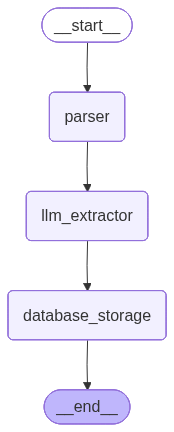

In [14]:
# Cell 11 — Build and run graph

from db_connect import init_db

init_db()

g = StateGraph(CVState)
g.add_node("parser",           parser)
g.add_node("llm_extractor",    llm_extractor)
g.add_node("database_storage", database_storage)

g.add_edge(START,              "parser")
g.add_edge("parser",           "llm_extractor")
g.add_edge("llm_extractor",    "database_storage")
g.add_edge("database_storage", END)

app = g.compile()
app

In [15]:
# Cell 12 — Run on your PDF

result = app.invoke({"pdf_path": "C:\\Projects\\Talash\\Cvs\\output_first_10_pages.pdf", "raw_texts": [], "all_results": []})

📄 Single PDF → 3 CV(s) detected

[1/3] Extracting → cv_1
   🔧 Inferred skills: []
   🔧 Inferred skills: ['Project Management', 'Support Engineering', 'Lecturing', 'Research', 'Data Analysis']
   ✅ Name         : MUHAMMAD SALMAN QAMAR
      Email        : None
      Education    : 5
      Experience   : 5
      Publications : 5
      Skills       : 5

[2/3] Extracting → cv_2
   🔧 Inferred skills: []
   🔧 Inferred skills: ['Research', 'Resource Allocation', 'NOMA', '5G Technologies', 'Wireless Communication']
   ✅ Name         : Aamina Akbar
      Email        : None
      Education    : 5
      Experience   : 2
      Publications : 4
      Skills       : 5

[3/3] Extracting → cv_3
   🔧 Inferred skills: []
   🔧 Inferred skills: []
   ✅ Name         : MUHAMMAD SHAHWAZ
      Email        : None
      Education    : 5
      Experience   : 3
      Publications : 0
      Skills       : 0
   💾 Stored: MUHAMMAD SALMAN QAMAR (cv_1)
   💾 Stored: Aamina Akbar (cv_2)
   💾 Stored: MUHAMMAD SHAHWAZ (

In [16]:
# Cell 13 — Inspect output

import pprint
pprint.pprint(result["all_results"][0], indent=2)

{ '_candidate_id': 'cv_1',
  '_skills_from_cv': False,
  'books': [],
  'education': [ { 'board': None,
                   'cgpa': 3.33,
                   'cgpa_scale': 4.0,
                   'degree': 'PhD',
                   'end_year': 2024,
                   'field': 'Electrical Engineering',
                   'institution': 'International Islamic university, Islamabad',
                   'normalized_percentage': 83.25,
                   'percentage': None,
                   'start_year': None},
                 { 'board': None,
                   'cgpa': 3.03,
                   'cgpa_scale': 4.0,
                   'degree': 'MS',
                   'end_year': 2014,
                   'field': 'Electrical Engineering',
                   'institution': 'COMSATS University, Islamabad, Attock '
                                  'Campus',
                   'normalized_percentage': 75.75,
                   'percentage': None,
                   'start_year': None},
       

In [17]:
# Cell — View Database Data
from db_connect import get_session
from db_models import Candidate

session = get_session()

try:
    # 1. Query all candidates from the database
    all_candidates = session.query(Candidate).all()
    
    print(f"📊 Total CVs in database: {len(all_candidates)}\n")
    print("=" * 60)

    # 2. Loop through each candidate and print their related data
    for cand in all_candidates:
        print(f"👤 Name: {cand.name} (DB ID: {cand.id} | System ID: {cand.candidate_id})")
        print(f"📧 Email: {cand.email} | 📱 Phone: {cand.phone}")
        
        # --- Print Education ---
        print("\n🎓 Education:")
        if not cand.education:
            print("   (No education data)")
        for edu in cand.education:
            # Notice how we access the new columns here!
            print(f"   - {edu.degree} ({edu.degree_level}) in {edu.field}")
            print(f"     {edu.institution} | Normalized Score: {edu.normalized_percentage}%")

        # --- Print Experience ---
        print("\n💼 Experience:")
        if not cand.experience:
            print("   (No experience data)")
        for exp in cand.experience:
            print(f"   - {exp.role} at {exp.company} ({exp.start_date} to {exp.end_date})")

        # --- Print Skills ---
        print("\n🛠️ Skills:")
        if not cand.skills:
            print("   (No skills data)")
        else:
            # We can use a list comprehension to grab just the skill names
            skill_list = [skill.skill_name for skill in cand.skills]
            print(f"   - {', '.join(skill_list)}")
            
            # Count how many were inferred by the LLM
            inferred_count = sum(1 for skill in cand.skills if skill.inferred)
            print(f"     ({inferred_count} of these were inferred by the LLM)")

        print("\n" + "=" * 60 + "\n")

except Exception as e:
    print(f"❌ Error fetching data: {e}")
finally:
    # Always close the session when you are done querying!
    session.close()

📊 Total CVs in database: 3

👤 Name: MUHAMMAD SALMAN QAMAR (DB ID: 1 | System ID: cv_1)
📧 Email: None | 📱 Phone: None

🎓 Education:
   - PhD (doctorate) in Electrical Engineering
     International Islamic university, Islamabad | Normalized Score: 83.25%
   - MS (postgrad) in Electrical Engineering
     COMSATS University, Islamabad, Attock Campus | Normalized Score: 75.75%
   - BSc (undergrad) in Electronics Engineering
     COMSATS University, Islamabad, Abbottabad Campus | Normalized Score: 69.84%
   - HSSC (school) in Pre-Engineering
     B.I.S.E Bannu | Normalized Score: 65.45%
   - SSC (school) in Science Subjects
     B.I.S.E Bannu | Normalized Score: 71.0%

💼 Experience:
   - Program Coordinator at Qurtuba University, D.I.Khan (2017-09 to 2023-08)
   - Support Engineer at Al-Rehman enterprises, Islamabad (2012-01 to 2015-08)
   - Lecturer at Qurtuba University, D.I.Khan (2015-08 to 2018-03)
   - Assistant Professor at Qurtuba University, D.I.Khan (2018-03 to 2023-08)
   - Associ

In [18]:
# Verification Cell — run this after the pipeline completes

import pprint
import json

candidate = result["all_results"][0]

print("=" * 60)
print("SCHEMA CHECK")
print("=" * 60)

# Check 1: No old keys
old_keys = ["journal_publications", "conference_papers", "ssc_hssc"]
for key in old_keys:
    status = "❌ STILL EXISTS" if key in candidate else "✅ Gone"
    print(f"  {key}: {status}")

# Check 2: Unified publications exist
pubs = candidate.get("publications", [])
print(f"\n  publications list: {len(pubs)} entries")
for p in pubs:
    print(f"    - type={p.get('type')} | year={p.get('year')} | role={p.get('authorship_role')}")

# Check 3: SSC/HSSC inside education
edu = candidate.get("education", [])
print(f"\n  education list: {len(edu)} entries")
for e in edu:
    print(f"    - degree={e.get('degree')} | cgpa={e.get('cgpa')} | scale={e.get('cgpa_scale')} | norm%={e.get('normalized_percentage')} | pct={e.get('percentage')}")

# Check 4: Experience dates format
exp = candidate.get("experience", [])
print(f"\n  experience list: {len(exp)} entries")
for e in exp:
    print(f"    - start={e.get('start_date')} | end={e.get('end_date')} | role={e.get('role')}")

# Check 5: Skills
skills = candidate.get("skills", [])
print(f"\n  skills ({len(skills)}): {skills}")

# Check 6: No N/A strings anywhere
raw_str = json.dumps(candidate)
na_count = raw_str.lower().count('"n/a"') + raw_str.lower().count('"not mentioned"')
print(f"\n  N/A strings remaining: {'❌ ' + str(na_count) + ' found' if na_count else '✅ None'}")

print("\n" + "=" * 60)
print("FULL DUMP")
print("=" * 60)
pprint.pprint(candidate, indent=2)

SCHEMA CHECK
  journal_publications: ✅ Gone
  conference_papers: ✅ Gone
  ssc_hssc: ✅ Gone

  publications list: 5 entries
    - type=journal | year=2025 | role=None
    - type=journal | year=2025 | role=None
    - type=journal | year=2021 | role=None
    - type=conference | year=2024 | role=None
    - type=journal | year=2024 | role=None

  education list: 5 entries
    - degree=PhD | cgpa=3.33 | scale=4.0 | norm%=83.25 | pct=None
    - degree=MS | cgpa=3.03 | scale=4.0 | norm%=75.75 | pct=None
    - degree=BSc | cgpa=None | scale=None | norm%=69.84 | pct=69.84
    - degree=HSSC | cgpa=None | scale=None | norm%=65.45 | pct=65.45
    - degree=SSC | cgpa=None | scale=None | norm%=71.0 | pct=71.0

  experience list: 5 entries
    - start=2017-09 | end=2023-08 | role=Program Coordinator
    - start=2012-01 | end=2015-08 | role=Support Engineer
    - start=2015-08 | end=2018-03 | role=Lecturer
    - start=2018-03 | end=2023-08 | role=Assistant Professor
    - start=2025-01 | end=None | rol